In [ ]:
import os, glob
from IPython.display import Image, display


In [ ]:
from IPython import display as ipython_display

In [ ]:
ipython_display.clear_output()

In [ ]:
!nvidia-smi

Fri May 29 13:50:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
HOME=os.getcwd()

In [ ]:
print(HOME)

/content/folders/BuildingCracks-1


In [ ]:
!pip install ultralytics

In [ ]:
import ultralytics

In [ ]:
ultralytics.checks()

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [ ]:
!mkdir {HOME}/direct

mkdir: cannot create directory ‘/content/folders’: File exists


In [ ]:
%cd {HOME}/direct

/content/folders


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="eUBAVEkpWCupFQnjP1q7")
project = rf.workspace("aiimages").project("buildingcracks")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 138.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BuildingCracks-1 in yolov8:: 100%|██████████| 1611/1611 [00:00<00:00, 9637.55it/s]


In [ ]:
%cd {HOME}

/content


In [ ]:
%cd {dataset.location}

/content/folders/BuildingCracks-1


In [ ]:
# Run

In [ ]:
!yolo task=detect mode=train model=yolov10n.pt data='/content/folders/BuildingCracks-1/data.yaml' epochs=50 imgsz=640 amp=False

In [ ]:
!yolo task=detect mode=val model=runs/detect/train-2/weights/best.pt data='/content/folders/BuildingCracks-1/data.yaml'

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,265,363 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 906.4±845.6 MB/s, size: 20.5 KB)
val: Scanning /content/folders/BuildingCracks-1/valid/labels.cache... 54 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 54/54 9.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.0it/s 2.0s
                   all         54        103      0.663      0.456      0.624      0.248
Speed: 9.0ms preprocess, 7.1ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
!yolo task=detect mode=predict model=runs/detect/train-2/weights/best.pt source="/imgs1.jpg"

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,265,363 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 /imgs1.jpg: 448x640 3 BuildingCrackss, 102.0ms
Speed: 8.5ms preprocess, 102.0ms inference, 20.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


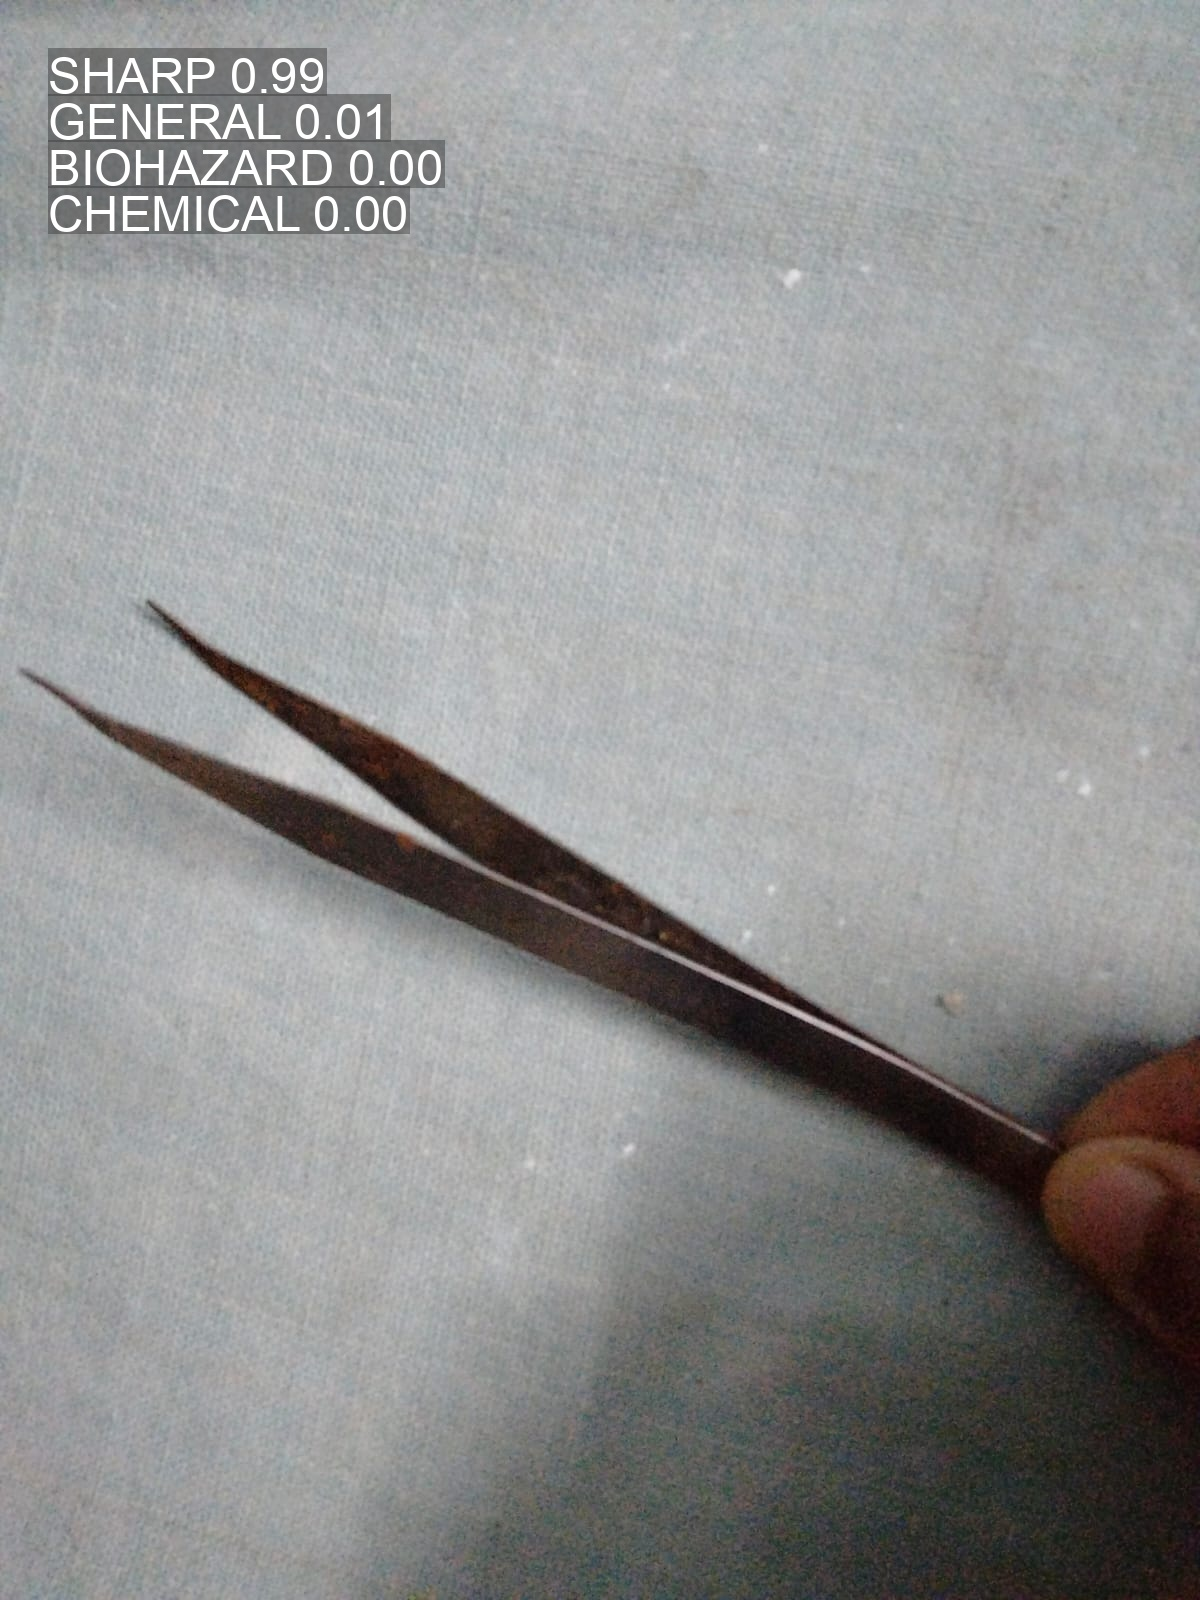

In [ ]:
'''from IPython.display import Image, display

display(Image("/content/runs/classify/predict/img7.jpg", width=450, height=450))'''

In [ ]:
!pip install onnx onnxruntime onnxconverter-common -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 9.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load your trained FP32 model
model = YOLO("/content/runs/detect/train-2/weights/best.pt")

# Export to ONNX with FP16 quantization applied
model.export(
    format="onnx",     # format conversion → produces best.onnx
    half=True,         # quantization → FP16 applied during export
    imgsz=640,
    dynamic=False
)

print("Conversion done!")
#print("Output file: runs/detect/crack_yolov10n_fp32/weights/best.onnx")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv10n summary (fused): 102 layers, 2,265,363 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from '/content/runs/detect/train-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.5 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.71'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 203ms
Prepared 2 packages in 34ms
Installed 2 packages in 7ms
 + colorama==0.4.6
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...


Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.94...
ONNX: converting to FP16...
ONNX: export success ✅ 3.0s, saved as '/content/runs/detect/train-2/weights/best.onnx' (4.5 MB)

Export complete (4.0s)
Results saved to /content/runs/detect/train-2/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/detect/train-2/weights/best.onnx imgsz=640 half
Validate:        yolo val task=detect model=/content/runs/detect/train-2/weights/best.onnx imgsz=640 data=/content/folders/BuildingCracks-1/data.yaml half 
Visualize:       https://netron.app
Conversion done!


In [ ]:
#optional

In [ ]:
import os

fp32_path = "runs/detect/train-2/weights/best.pt"
fp16_path = "runs/detect/train-2/weights/best.onnx"

fp32_size = os.path.getsize(fp32_path) / 1e6
fp16_size = os.path.getsize(fp16_path) / 1e6

print(f"FP32 model size: {fp32_size:.2f} MB")
print(f"FP16 ONNX size:  {fp16_size:.2f} MB")
print(f"Size reduction:  {((fp32_size - fp16_size)/fp32_size)*100:.1f}%")

FP32 model size: 5.75 MB
FP16 ONNX size:  4.72 MB
Size reduction:  17.9%


In [ ]:
from ultralytics import YOLO

# Load the ONNX model directly
onnx_model = YOLO("runs/detect/train-2/weights/best.onnx")

# Run validation — this gives your Quantized mAP50-95
metrics = onnx_model.val(data=f"/content/folders/BuildingCracks-1/data.yaml")

print(f"Quantized mAP50:    {metrics.box.map50:.4f}")
print(f"Quantized mAP50-95: {metrics.box.map:.4f}")   # ← record this

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading runs/detect/train-2/weights/best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 5 packages in 142ms
Prepared 1 package in 3.04s
Installed 1 package in 134ms
 + onnxruntime-gpu==1.26.0

requirements: AutoUpdate success ✅ 3.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1146.9±433.6 MB/s, size: 39.6 KB)
val: Scanning /content/folders/BuildingCracks-1/valid/labels.cache... 54 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 54/54 7.5Mit/s 0.0s
                 Class     Images  Instances      Box(P 